# Supplementary Fig. 11 — choosing a p-value threshold for calling real variants

In each panel the **top** plot shows the number of variants called (orange) and the expected number of false positives under the null model (blue) vs the
p-value threshold; the **bottom** plot shows the resulting false-discovery rate (FDR).

- **a** — *simulated* samples, all errors ε 10⁻³–10⁻¹ (variant count ≈ expected; FDR ~100 %).
- **b** — *simulated* samples, lower errors ε 10⁻⁴–10⁻³ (observed count consistently *lower* than expected).
- **c** — *real* pre-AML + control samples (lane SLX_20124); the dotted line marks the chosen threshold p = 6×10⁻⁶ (FDR ≈ 5 %).

*Part A (below) runs the simulated pipeline for a & b; Part B runs the real-sample pipeline for c.
Run the notebook top to bottom.*

## Data availability

**Panels a and b** run from `Data_files/Simulation_v2_beta_binomials_40_samples_delta_initialsied_from_variance_or_MOM.csv`,
a simulated beta-binomial dataset included here. It is entirely synthetic — no participant data — so these
two panels reproduce from this repository alone.

**Panel c** additionally needs `Data_files/SLX_20124_dataframe_all_positions_results_cases_and_controls_DCS.csv`,
the per-position, per-sample DCS error-model table for lane SLX_20124. It holds variant and depth counts for
every sample at every position in the panel, which carries germline genotype information, and it is **not
distributed with this code**. It is not deposited itself, but the per-sample DCS all-positions VCFs it is
assembled from are: those are deposited under controlled access in the European Genome-phenome Archive
and released to approved researchers via a Data Access Committee. **Supplementary Fig. 12** builds this
matrix from them and writes it into `Data_files/`.

The COSMIC hotspot list panel c uses (`Data_files/All_SNV_panel_positions_seen_in_COSMIC_haem_lymphoid.csv`)
is included here, so the annotation cells that derive it can be skipped.

In [264]:
# imported packages
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy.optimize
from scipy.stats import betabinom
from scipy.stats import binom
import pandas as pd
import csv
import time

# embed fonts as text (not outlines) so the vector PDF stays editable
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Helvetica']

In [265]:
# Lists of colors for plots
c0 = (0.76, 0.76, 0.76)
c1 = (1.00, 0.18, 0.33);
c2 = (1.00, 0.23, 0.19);
c3 = (1.00, 0.58, 0.00);
c4 = (1.00, 0.80, 0.00);
c5 = (0.30, 0.85, 0.39);
c6 = (0.35, 0.78, 0.98);
c7 = (0.20, 0.67, 0.86);
c8 = (0.00, 0.48, 1.00);
c9 = (0.35, 0.34, 0.84);
c10 = (0.00, 0.31, 0.57);
c11 = (0.12, 0.29, 0.69);
c12 = (0.17, 0.17, 0.42);
c13 = (1.00, 1.00, 1.00);
c14 = (0.77, 0.04, 0.00);

In [266]:
#define the colors from colorbrewer2
orange1 = '#feedde'
orange2 = '#fdbe85'
orange3 = '#fd8d3c'
orange4 = '#e6550d'
orange5 = '#a63603'
blue1 = '#eff3ff'
blue2 = '#bdd7e7'
blue3 = '#6baed6'
blue4 = '#3182bd'
blue5 = '#08519c'
green1 = '#edf8e9'
green2 = '#bae4b3'
green3 = '#74c476'
green4 = '#31a354'
green5 = '#006d2c'
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'
purple1 = '#f2f0f7'
purple2 = '#cbc9e2'
purple3 = '#9e9ac8'
purple4 = '#756bb1'
purple5 = '#54278f'
red1 = '#fee5d9'
red2 = '#fcae91'
red3 = '#fb6a4a'
red4 = '#de2d26'
red5 = '#a50f15'
# yellow = '#ffffd4'

# Part A — simulated samples (panels a & b)

### How the simulated dataset was generated
The file read below is a synthetic beta-binomial dataset, generated once outside this notebook by
`Supplementary_Fig_11_Simulating_beta_binomial_dataset.ipynb`.
It contains no participant data.

Each row is one simulated panel "position", over a 50 x 50 grid of parameters:

- position error rate `epsilon`, log-spaced from 1e-4 to 1
- dispersion `delta`, log-spaced from 1e-5 to 1e3
- 40 samples per position, all at a fixed depth of 1800 reads (chosen to match the real DCS depth)

Variant read counts are drawn from `scipy.stats.betabinom.rvs(n, a, b, size=40)`, with `a` and `b`
from `a_b(epsilon, delta)`. Where `delta * epsilon < 1e-7` the beta-binomial is indistinguishable from
its binomial limit, so counts are drawn from `numpy.random.binomial(n, epsilon, 40)` instead. Grid points
where all 40 samples drew zero variant reads are dropped.

For every position, `epsilon` and `delta` are then re-estimated from the simulated counts by two routes —
`delta` initialised from the variance, and `delta` from method of moments — each passed to
`beta_binomial_MLE`. Those estimates are the `epsilon_estimate` / `delta_estimate_from_variance` /
`MOM_delta_estimate` / `MLE results (...)` columns. The panels below use the *true* `actual_epsilon` and
`actual_delta` rather than the estimates, so no fitting is repeated here.

In [267]:
def convert_string_to_list(string_list):
    new_list = []
    string_list = string_list.replace('[','')
    string_list = string_list.replace(']','')
    string_list = string_list.split(',')
    for i in string_list:
        new_list.append(int(i))
        
    return new_list

In [268]:
def a_b(epsilon, delta):
    a = 1/delta
    b = (1-epsilon)/(delta*epsilon)
    return a, b

In [269]:
def number_false_positive(number_positions, p_value_threshold, number_people):
    return number_positions*p_value_threshold*number_people

In [270]:
df = pd.read_csv('Data_files/Simulation_v2_beta_binomials_40_samples_delta_initialsied_from_variance_or_MOM.csv')
df = df.drop(columns = 'Unnamed: 0')
df['variant_reads']=df['variant_reads'].apply(convert_string_to_list)
df['depth_reads']=df['depth_reads'].apply(convert_string_to_list)
# df

In [271]:
def binomial_calling_actual_epsilon(sample_list, p_value_threshold, epsilon):
    real_variants = {}
    remaining_samples = []
        
    position_error_rate = epsilon
    
    for sample in sample_list: #iterate through the list of samples [(sample_name, variant depth, total depth), (sample_name, variant depth, total depth).....]
        sample_name = sample[0]
        sample_variant_depth = sample[1]
        sample_total_depth = sample[2]
        sample_VAF = sample_variant_depth/sample_total_depth
        #calculate the p-value for each sample
        p_value = binom.sf(sample_variant_depth-1, sample_total_depth, position_error_rate) #subtract 1 from variant depth because should be p-value for >= that number of variant reads
        if (sample_variant_depth >0) and p_value < p_value_threshold: #if p-value < threshold, call as real
            real_variants[sample_name] = {}
            real_variants[sample_name] = {'variant_depth': sample_variant_depth, 'total_depth': sample_total_depth, 'p_value': p_value}
        else: #if p-value not <threshold, then call as an error
            remaining_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, p_value))
            
    return remaining_samples, real_variants, number_non_zero

In [272]:
def beta_binomial_no_iteration_actual_epsilon_delta(sample_list, p_value_threshold, epsilon, delta):
    real_variants = {}
    error_samples = []

    a, b = a_b(epsilon, delta)
    
    #Using the inferred value for epsilon and delta, calculate the p-value for each sample...
    for sample in sample_list: #sample list includes the excluded sample
        sample_name = sample[0]
        sample_variant_depth = sample[1]
        sample_total_depth = sample[2]
        sample_VAF = sample_variant_depth/sample_total_depth
        p_value = betabinom.sf(sample_variant_depth-1, sample_total_depth, a, b) #subtract 1 from variant depth because should be p-value for >= that number of variant reads
        if (sample_variant_depth >0) and (p_value < p_value_threshold):
            real_variants[sample_name] = {'variant_depth': sample_variant_depth, 'total_depth': sample_total_depth, 
                                          'p_value': p_value, 'fitting_method': 'beta-binomial'}
        #if the p-value isn't less than the threshold, add the sample to a 'remaining variants' list
        else:
            error_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, p_value))

            
    return error_samples, real_variants

In [273]:
def non_iterative_variant_calling_actual_epsilon_delta(sample_list, p_value_threshold, number_non_zero, epsilon, delta):
    positions_p_values_errors = {}
    positions_p_values_real_variants = {}
    positions_real_variants = []

    total_variants_called = 0

    if number_non_zero<=1: #binomial
        remaining_samples, real_variants = binomial_calling_actual_epsilon(sample_list, p_value_threshold, epsilon)

        total_variants_called+=len(real_variants)
        positions_real_variants.append(real_variants)


    #if more than one non-zero variant read...
    if number_non_zero>1:
        remaining_samples, real_variants = beta_binomial_no_iteration_actual_epsilon_delta(sample_list, p_value_threshold, epsilon, delta)

        total_variants_called+=len(real_variants)
        positions_real_variants.append(real_variants) #keep a list of the real variants

    return positions_real_variants, total_variants_called

In [274]:
def simulated_non_iterative_beta_binomial_multi_p_values_actual_delta_epsilon(simulated_positions_df_40, p_value_list):
    
    df40list = simulated_positions_df_40.values.tolist()
    
    df40list_without_duplicates = []
    
    for i in df40list:
        if i not in df40list_without_duplicates:
            df40list_without_duplicates.append(i)

    n = 0
    start_time = time.time()
    reset_time = time.time()

    position_error_sample_p_values = {}
    position_real_sample_p_values = {}
    position_real_variants = {}
    
    p_value_variants_detected = {}

    for i in df40list_without_duplicates:
        epsilon = i[0]
        delta = i[1]
        variant_reads = i[8]
        depth_reads = i[9]

        position_label = (epsilon, delta, n)

        number_samples = 0
        number_non_zero = 0
        position_sample_list = []

        m=0
        for var, dep in zip(variant_reads, depth_reads):
            var_depth = int(var)
            tot_depth = int(dep)

            if tot_depth!=0:
                number_samples+=1
                VAF = var/dep
                sample_number = m
                position_sample_list.append((sample_number, var_depth, tot_depth, VAF))
                if var!=0:
                    number_non_zero+=1
            m+=1

        position_real_variants[position_label] = {}

        if number_samples>0:
            total_variants_called = 1
            for p_value_threshold in p_value_list:
                if total_variants_called>0: #i.e. no point trying lower p-value threshold if at higher threshold no variants were called
                    
                    real_variants, total_variants_called = non_iterative_variant_calling_actual_epsilon_delta(position_sample_list, p_value_threshold, number_non_zero, epsilon, delta)
                    position_real_variants[position_label][p_value_threshold] = real_variants 
#                     print('number real variants with p-value '+str(p_value_threshold)+' = ', total_variants_called)

                    if p_value_threshold in p_value_variants_detected.keys():
                        p_value_variants_detected[p_value_threshold]+=total_variants_called
                    else:
                        p_value_variants_detected[p_value_threshold]=total_variants_called
                else:
                    break

        n+=1
                
        # if n%5==0:
        #     time_now = time.time()
        #     print('total positions fitted = '+str(n)+' (last 5 in '+str(int(time_now - reset_time))+' seconds).  Total time elapsed = '+str(round((time_now - start_time)/60, 2))+' minutes')
        #     reset_time = time.time()
            
    return position_real_variants, p_value_variants_detected

In [275]:
def BB_likelihood(params, var_depths, total_depths):
#     print(params)
    epsilon = params[0]
    delta = params[1]
    a = 1/delta
    b = (1-epsilon)/(delta*epsilon)

    log_sample_BBs = []
    sample_BBs = []
    
    for sample_variant_depth, sample_total_depth in zip(var_depths, total_depths):
        BB = betabinom.pmf(sample_variant_depth, sample_total_depth, a, b) #calculate the beta-binomial likelihood of measuring that number of variant reads, given the sample depth, position error rate and delta
        log_sample_BBs.append(np.log(BB))
        sample_BBs.append(BB)

    model_likelihood_log = np.sum(log_sample_BBs)

    if delta<1e-08/epsilon:
        model_likelihood_log = -100000000000
        
    if epsilon<0:
        model_likelihood_log = -100000000000
        
    if epsilon>1:
        model_likelihood_log = -100000000000
        
#     print(-model_likelihood_log)
# 
    return -model_likelihood_log

In [276]:
def estimate_delta_method_of_moments(variant_reads, total_depth_reads):
    number_samples = len(variant_reads)
    mean_depth = np.mean(total_depth_reads)
    error_rate_estimate = (np.sum(variant_reads))/np.sum(total_depth_reads)
    
    #calculate the 1st raw sample moment
    k = 1
    m_1 = (sum([var_read**k for var_read in variant_reads]))/number_samples

    #calculate the 2nd raw sample moment
    k = 2
    m_2 = (sum([var_read**k for var_read in variant_reads]))/number_samples

    try:
        alpha = (mean_depth*m_1-m_2)/(mean_depth*((m_2/m_1)-m_1-1)+m_1)
    except ZeroDivisionError:
        alpha = 0

    try:
        delta = 1/alpha
    except ZeroDivisionError:
        delta = 0
        
    try:
        beta = ((mean_depth-m_1)*(mean_depth-m_2/m_1))/(mean_depth*((m_2/m_1)-m_1-1)+m_1)
    except ZeroDivisionError:
        beta = 0

    return delta

In [277]:
def beta_binomial_MLE(variant_reads_list, sample_depths, position_error_rate_initial_guess, position_delta_initial_guess):

    initial_guess = [position_error_rate_initial_guess, position_delta_initial_guess]
    
    #Calculate the most likely episolon and delta         
    optimization = scipy.optimize.minimize(BB_likelihood, initial_guess, args=(variant_reads_list, sample_depths, ), 
                                            method='Nelder-Mead', options = {'maxiter': 10000, 'maxfev': 10000})
    optimization_minima = optimization['fun']
    optimization_outcome = optimization['success']
    optimization_message = optimization['message']
    epsilon = optimization['x'][0]
    delta = optimization['x'][1]

    position_MLE_results = (epsilon, delta, optimization_outcome, optimization_message, optimization_minima)
        
    return position_MLE_results

In [278]:
def binomial_calling(sample_list, p_value_threshold, iteration):
    real_variants = {}
    remaining_samples = []
    
    var_depths = []
    tot_depths = []
    for sample in sample_list:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        
    position_error_rate = np.sum(var_depths)/np.sum(tot_depths)
    
    for sample in sample_list: #iterate through the list of samples [(sample_name, variant depth, total depth), (sample_name, variant depth, total depth).....]
        sample_name = sample[0]
        sample_variant_depth = sample[1]
        sample_total_depth = sample[2]
        sample_VAF = sample_variant_depth/sample_total_depth
        #calculate the p-value for each sample
        p_value = binom.sf(sample_variant_depth-1, sample_total_depth, position_error_rate) #subtract 1 from variant depth because should be p-value for >= that number of variant reads
        if (sample_variant_depth >0) and p_value < p_value_threshold: #if p-value < threshold, call as real
            real_variants[sample_name] = {}
            real_variants[sample_name] = {'variant_depth': sample_variant_depth, 'total_depth': sample_total_depth, 'iteration called at': iteration, 
                                          'p_value': p_value, 'fitting_method': 'binomial'}
        else: #if p-value not <threshold, then call as an error
            remaining_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, p_value))
            
    #calculate the error_rate of the samples that weren't called as real:
    var_depths = []
    tot_depths = []
    number_non_zero = 0
    for sample in remaining_samples:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        if sample[1]>0:
            number_non_zero+=1

    final_position_error_rate = np.sum(var_depths)/np.sum(tot_depths)
            
    return remaining_samples, real_variants, position_error_rate, final_position_error_rate, number_non_zero

In [279]:
def beta_binomial_no_iteration(sample_list, p_value_threshold):
    real_variants = {}
    error_samples = []

    sample_list_to_fit = sample_list # do not exclude the most extreme value

    #calculate an error rate estimate to use for the MLE
    var_depths = []
    tot_depths = []
    for sample in sample_list_to_fit:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        
    mean_depth = np.mean(tot_depths)

    error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
    delta_estimate = estimate_delta_method_of_moments(var_depths, tot_depths)
    if delta_estimate < 0:
        delta_estimate = 1e-04/error_rate_estimate
    
    #Calculate the MLE for epsilon and delta
    MLE = beta_binomial_MLE(var_depths, tot_depths, error_rate_estimate, delta_estimate) 
#     print(MLE)
    epsilon = MLE[0]
    delta = MLE[1]
    outcome = MLE[2]
    comment = MLE[3]
    minima = MLE[4]
    a, b = a_b(epsilon, delta)
    
    #Using the inferred value for epsilon and delta, calculate the p-value for each sample...
    for sample in sample_list: #sample list includes the excluded sample
        sample_name = sample[0]
        sample_variant_depth = sample[1]
        sample_total_depth = sample[2]
        sample_VAF = sample_variant_depth/sample_total_depth
        p_value = betabinom.sf(sample_variant_depth-1, sample_total_depth, a, b) #subtract 1 from variant depth because should be p-value for >= that number of variant reads
        if (sample_variant_depth >0) and (p_value < p_value_threshold):
            real_variants[sample_name] = {'variant_depth': sample_variant_depth, 'total_depth': sample_total_depth, 
                                          'p_value': p_value, 'fitting_method': 'beta-binomial'}
        #if the p-value isn't less than the threshold, add the sample to a 'remaining variants' list
        else:
            error_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, p_value))
            
    #calculate the error_rate and delta of the samples that weren't called as real:
    var_depths = []
    tot_depths = []
    number_non_zero = 0
    for sample in error_samples:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        if sample[1]>0:
            number_non_zero+=1

    mean_depth = np.mean(tot_depths)
    
    if number_non_zero>=1:
        final_error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
        final_delta_estimate = estimate_delta_method_of_moments(var_depths, tot_depths)
        if final_delta_estimate < 0:
            final_delta_estimate = 1e-04/final_error_rate_estimate

        MLE = beta_binomial_MLE(var_depths, tot_depths, final_error_rate_estimate, final_delta_estimate)
        final_epsilon = MLE[0]
        final_delta = MLE[1]
        final_outcome = MLE[2]
        final_comment = MLE[3]
        final_minima = MLE[4]
        
    if number_non_zero<1:
        final_error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
        final_delta_estimate = np.nan
        final_epsilon = np.sum(var_depths)/np.sum(tot_depths)
        final_delta = np.nan
        final_outcome = np.nan
        final_comment = np.nan
        final_minima = np.nan
            
    return error_samples, real_variants, outcome, comment, epsilon, delta, error_rate_estimate, delta_estimate, minima, final_epsilon, final_delta, final_error_rate_estimate, final_delta_estimate, number_non_zero

In [280]:
def non_iterative_variant_calling(sample_list, p_value_threshold, number_non_zero):
    positions_MLEs = {}
    positions_p_values_errors = {}
    positions_p_values_real_variants = {}
    positions_real_variants = []

    total_variants_called = 0

    if number_non_zero<=1: #fit a binomial
        remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = binomial_calling(sample_list, p_value_threshold, 1)
        final_delta = np.nan #because binomial
        outcome = np.nan
        comment = np.nan

        total_variants_called+=len(real_variants)
        positions_real_variants.append(real_variants)
        fitting_method = 'binomial'


    #if more than one non-zero variant read...
    if number_non_zero>1:
        final_fitting_method = 'beta-binomial'
        
        remaining_samples, real_variants, outcome, comment, epsilon, delta, epsilon_initialisation, delta_initialisation, minima, final_epsilon, final_delta, final_epsilon_initialisation, final_delta_initialisation, number_non_zero = beta_binomial_no_iteration(sample_list, p_value_threshold)

        total_variants_called+=len(real_variants)
        positions_real_variants.append(real_variants) #keep a list of the real variants
        fitting_method = 'beta-binomial'

    positions_MLEs= {'fitting methods': fitting_method, 'final position error rate': final_epsilon, 'final delta': final_delta, 
                                              'total variants called': total_variants_called,
                                             'MLE outcomes': outcome,
                                             'MLE comments': comment}

    return positions_MLEs, positions_real_variants, total_variants_called

In [293]:
def simulated_non_iterative_beta_binomial_multi_p_values(simulated_positions_df_40, p_value_list):
    
    df40list = simulated_positions_df_40.values.tolist()
    
    df40list_without_duplicates = []
    
    for i in df40list:
        if i not in df40list_without_duplicates:
            df40list_without_duplicates.append(i)

    n = 0
    start_time = time.time()
    reset_time = time.time()

    position_MLEs = {}
    position_error_sample_p_values = {}
    position_real_sample_p_values = {}
    position_real_variants = {}
    
    p_value_variants_detected = {}

    for i in df40list_without_duplicates:
        epsilon = i[0]
        delta = i[1]
        variant_reads = i[8]
        depth_reads = i[9]

        position_label = (epsilon, delta, n)

        number_samples = 0
        number_non_zero = 0
        position_sample_list = []

        m=0
        for var, dep in zip(variant_reads, depth_reads):
            var_depth = int(var)
            tot_depth = int(dep)

            if tot_depth!=0:
                number_samples+=1
                VAF = var/dep
                sample_number = m
                position_sample_list.append((sample_number, var_depth, tot_depth, VAF))
                if var!=0:
                    number_non_zero+=1
            m+=1

        position_MLEs[position_label] = {}
        position_real_variants[position_label] = {}

        if number_samples>0:
            total_variants_called = 1
            for p_value_threshold in p_value_list:
                if total_variants_called>0: #i.e. no point trying lower p-value threshold if at higher threshold no variants were called
                    
                    MLE_outcomes, real_variants, total_variants_called = non_iterative_variant_calling(position_sample_list, p_value_threshold, number_non_zero)
                    position_MLEs[position_label][p_value_threshold]= MLE_outcomes
                    position_real_variants[position_label][p_value_threshold] = real_variants 
#                     print('number real variants with p-value '+str(p_value_threshold)+' = ', total_variants_called)

                    if p_value_threshold in p_value_variants_detected.keys():
                        p_value_variants_detected[p_value_threshold]+=total_variants_called
                    else:
                        p_value_variants_detected[p_value_threshold]=total_variants_called
                else:
                    break

        n+=1
                
        if n%5==0:
            time_now = time.time()
            # print('total positions fitted = '+str(n)+' (last 5 in '+str(int(time_now - reset_time))+' seconds).  Total time elapsed = '+str(round((time_now - start_time)/60, 2))+' minutes')
            reset_time = time.time()
            
    return position_MLEs, position_real_variants, p_value_variants_detected

In [294]:
p_values_list = list(np.logspace(-6, 0, 37))
# p_values_list.append(1/2500)
p_values_list = sorted(p_values_list, reverse = True)
# p_values_list

In [295]:
#LOOK AT A REDUCED NUMBER OF POSITIONS
simulated_positions_df_40_filter = df[df['actual_epsilon']>1e-3]
simulated_positions_df_40_filter = simulated_positions_df_40_filter[simulated_positions_df_40_filter['actual_epsilon']<1e-1]
simulated_positions_df_40_filter = simulated_positions_df_40_filter[simulated_positions_df_40_filter['actual_delta']>1e-2]
simulated_positions_df_40_filter = simulated_positions_df_40_filter[simulated_positions_df_40_filter['actual_delta']<1]
# simulated_positions_df_40_filter

In [296]:
sim40filt_position_MLEs, sim40filt_position_real_variants, sim40filt_p_value_variants_detected = simulated_non_iterative_beta_binomial_multi_p_values(simulated_positions_df_40_filter, p_values_list)

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_31706/1587256314.py:13: RuntimeWarning: divide by zero encountered in log
  log_sample_BBs.append(np.log(BB))
/opt/anaconda3/envs/fastlab/lib/python3.11/site-packages/scipy/stats/_discrete_distns.py:254: RuntimeWarning: overflow encountered in exp
  return exp(self._logpmf(x, n, a, b))
/opt/anaconda3/envs/fastlab/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/fastlab/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_31706/3385506195.py:71: RuntimeWarning: invalid value encountered in scalar divide
  final_error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_31706/3385506195.py:73: R

In [297]:
FDR_by_p_value_filt = {}

for p_value in p_values_list:
    if p_value in sim40filt_p_value_variants_detected.keys():
        variants_called = sim40filt_p_value_variants_detected[p_value]
    else:
        variants_called = 0
    expected_false = number_false_positive(len(sim40filt_position_real_variants), p_value, 40)
#     print('number of positions = ', len(sim40filt_position_real_variants))
    try:
        false_discovery_rate = expected_false/variants_called
    except ZeroDivisionError:
        #no variants called at this threshold: expected/called is undefined, so the FDR is
        #capped at 1.0 (100%) rather than 0, which would fall off the bottom of the log axis
        false_discovery_rate = 1.0
    FDR_by_p_value_filt[p_value]=(variants_called, expected_false, false_discovery_rate)
    
# FDR_by_p_value_filt

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_31706/3388100946.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  false_discovery_rate = expected_false/variants_called


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


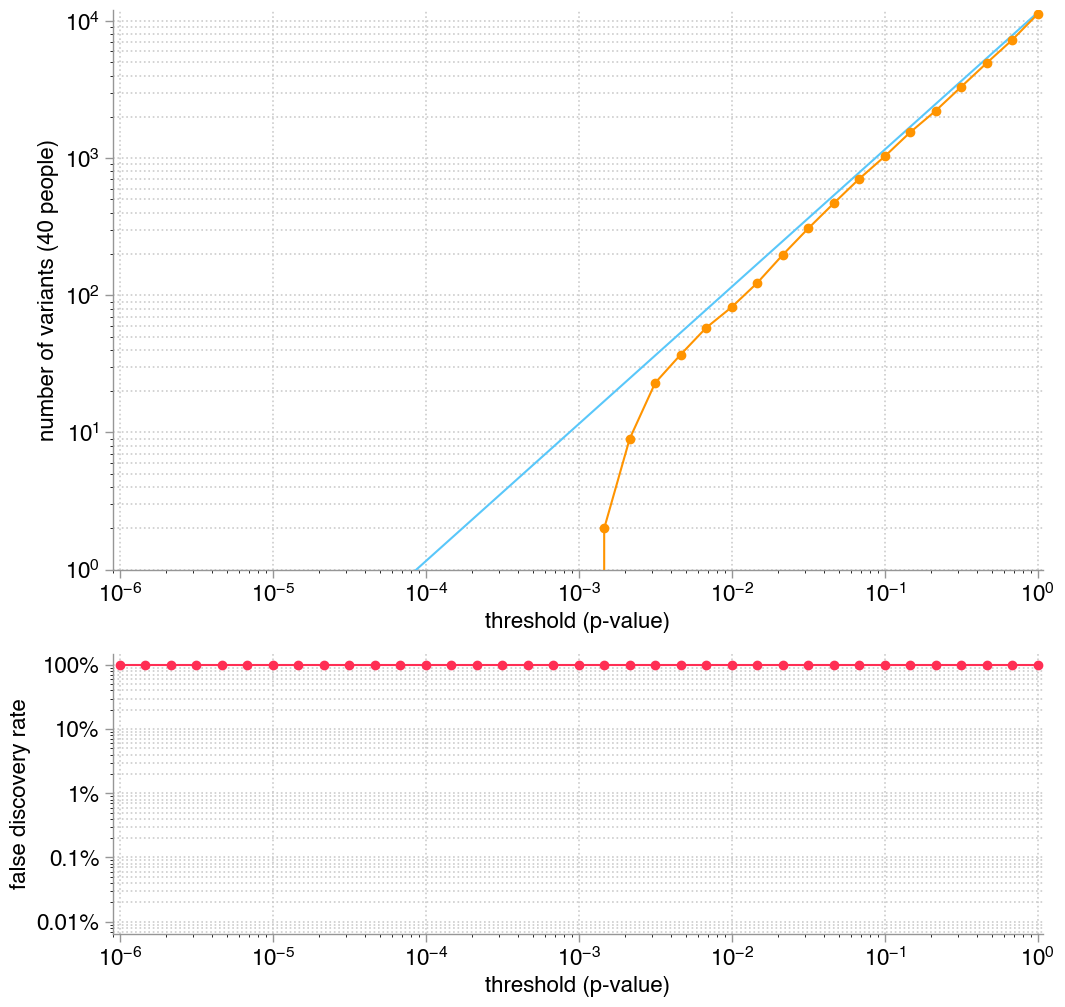

In [ ]:
#plot false discovery rate
fig, axes = plt.subplots(2, 1, figsize = (12, 12), gridspec_kw={'height_ratios':[2,1]})

ax1 = axes[0]
ax2 = axes[1]

number_of_positions = len(sim40filt_position_real_variants)

x1 = []
y1 = []

x2 = []
y2 = []

for k, v in FDR_by_p_value_filt.items():
    x1.append(k)
    y1.append(v[0])
    
    x2.append(k)
    FDR = v[2]
    if FDR>1.0:
        FDR = 1.0
    y2.append(FDR)

ax1.plot(x1, y1, color = c3, zorder = 60)
ax1.scatter(x1, y1, color = c3, zorder = 60)
    
ax2.plot(x2, y2, color = c1, zorder = 60)
ax2.scatter(x2, y2, color = c1, zorder = 60)

ax1.set_ylabel('number of variants (40 people)', fontsize = 16)
ax2.set_ylabel('false discovery rate', fontsize = 16)

# ax1.plot([1/(len(sim40filt_position_real_variants)*40), 1], [40, (len(sim40filt_position_MLEs)*40)], color = c6)
min_p_value = min(p_values_list)
max_p_value = max(p_values_list)

ax1.plot([min_p_value, 1], [min_p_value*40*number_of_positions, 40*number_of_positions], color = c6, zorder = 50)

for ax in [ax1, ax2]:
    ax.set_xlabel('threshold (p-value)', fontsize = 16)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.xaxis.set_tick_params(width=1, color = grey3, length = 6)
    ax.yaxis.set_tick_params(width=1, color = grey3, length = 6)

    for item in (ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(16)

    #Only show the required axis lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color(grey3)

    ax.grid(axis = 'y', which = 'both', lw = 1.2, zorder = 0, linestyle = ':', color = grey2)
    ax.grid(axis = 'x', which = 'major', lw = 1.2, zorder = 0, linestyle = ':', color = grey2)
    
ax2.set_yticks([0.0001, 0.001, 0.01, 0.1, 1.0])
ax2.set_yticklabels(['0.01%', '0.1%', '1%', '10%', '100%'])

# ax2.plot([1/number_of_positions, 1/number_of_positions], [0.000065, 1.0], color = grey4, lw = 2.5, linestyle = ':', zorder = 50)

ax1.set_xlim(9e-7, 1.08)
ax2.set_xlim(9e-7, 1.08)

ax1.set_ylim(1, number_of_positions*40*1.05)
ax2.set_ylim(0.000065, 1.5)

plt.show()

In [299]:
#LOOK AT A REDUCED NUMBER OF POSITIONS
simulated_positions_df_40_low = df[df['actual_epsilon']<1e-3] #i.e. just look at positions that have error rates between 1e-4 and 1e-3
# simulated_positions_df_40_low = simulated_positions_df_40_low[simulated_positions_df_40_low['actual_epsilon']<1e-1]
simulated_positions_df_40_low = simulated_positions_df_40_low[simulated_positions_df_40_low['actual_delta']>1e-3]
simulated_positions_df_40_low = simulated_positions_df_40_low[simulated_positions_df_40_low['actual_delta']<1]
# simulated_positions_df_40_low

In [300]:
sim40low_position_MLEs, sim40low_position_real_variants, sim40low_p_value_variants_detected = simulated_non_iterative_beta_binomial_multi_p_values(simulated_positions_df_40_low, p_values_list)

/opt/anaconda3/envs/fastlab/lib/python3.11/site-packages/scipy/stats/_discrete_distns.py:254: RuntimeWarning: overflow encountered in exp
  return exp(self._logpmf(x, n, a, b))
/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_31706/1587256314.py:13: RuntimeWarning: divide by zero encountered in log
  log_sample_BBs.append(np.log(BB))


In [301]:
FDR_by_p_value_DCS_low = {}

for p_value in p_values_list:
    if p_value in sim40low_p_value_variants_detected.keys():
        variants_called = sim40low_p_value_variants_detected[p_value]
    else:
        variants_called = 0
    expected_false = number_false_positive(len(sim40low_position_real_variants), p_value, 40)
    try:
        false_discovery_rate = expected_false/variants_called
    except ZeroDivisionError:
        #no variants called at this threshold: expected/called is undefined, so the FDR is
        #capped at 1.0 (100%) rather than 0, which would fall off the bottom of the log axis
        false_discovery_rate = 1.0
    FDR_by_p_value_DCS_low[p_value]=(variants_called, expected_false, false_discovery_rate)
    
# FDR_by_p_value_DCS_low

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_31706/3583597016.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  false_discovery_rate = expected_false/variants_called


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


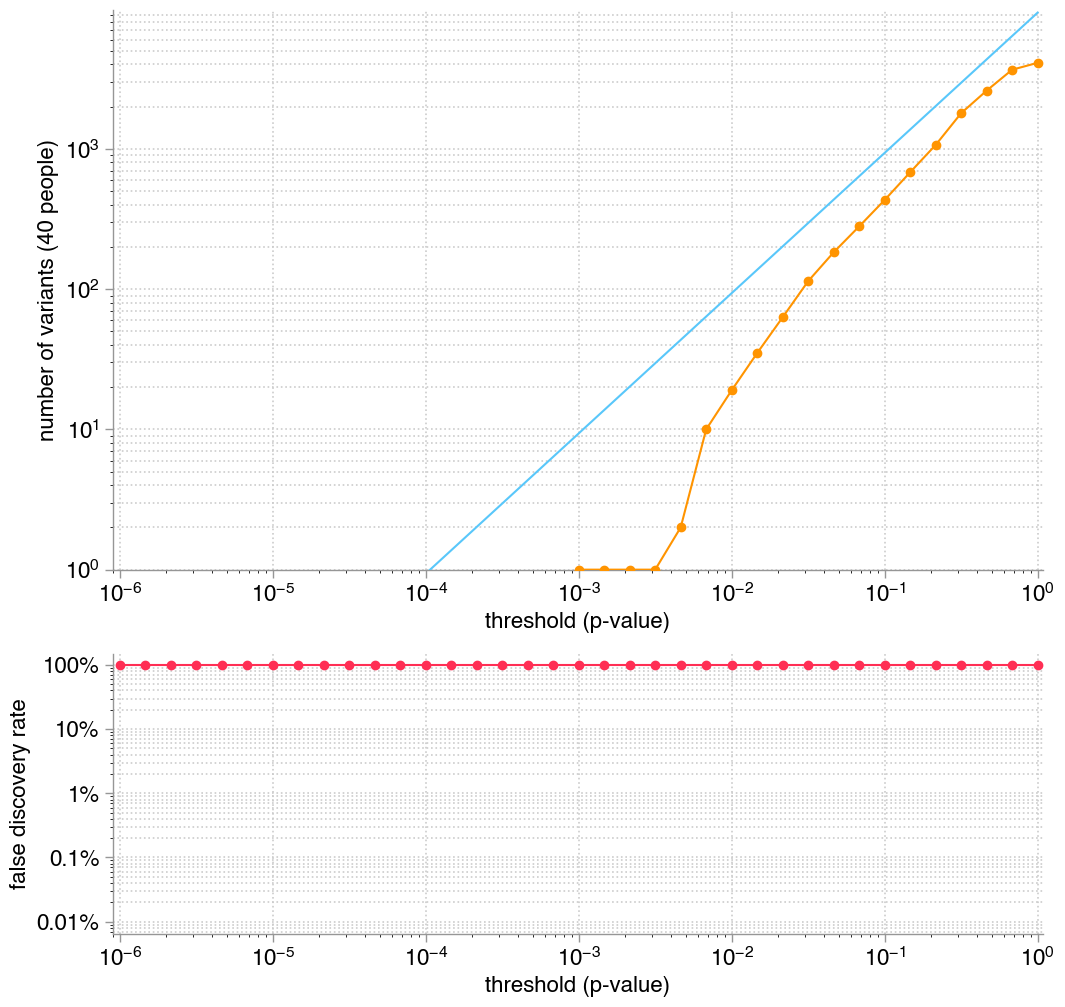

In [ ]:
#plot false discovery rate
fig, axes = plt.subplots(2, 1, figsize = (12, 12), gridspec_kw={'height_ratios':[2,1]})

ax1 = axes[0]
ax2 = axes[1]

number_of_positions = len(sim40low_position_real_variants)

x1 = []
y1 = []

x2 = []
y2 = []

for k, v in FDR_by_p_value_DCS_low.items():
    x1.append(k)
    y1.append(v[0])
    
    x2.append(k)
    FDR = v[2]
    if FDR>1.0:
        FDR = 1.0
    y2.append(FDR)

ax1.plot(x1, y1, color = c3, zorder = 60)
ax1.scatter(x1, y1, color = c3, zorder = 60)
    
ax2.plot(x2, y2, color = c1, zorder = 60)
ax2.scatter(x2, y2, color = c1, zorder = 60)

ax1.set_ylabel('number of variants (40 people)', fontsize = 16)
ax2.set_ylabel('false discovery rate', fontsize = 16)

# ax1.plot([1/(len(sim40filt_position_real_variants)*40), 1], [40, (len(sim40filt_position_MLEs)*40)], color = c6)
min_p_value = min(p_values_list)
max_p_value = max(p_values_list)

ax1.plot([min_p_value, 1], [min_p_value*40*number_of_positions, 40*number_of_positions], color = c6, zorder = 50)

for ax in [ax1, ax2]:
    ax.set_xlabel('threshold (p-value)', fontsize = 16)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.xaxis.set_tick_params(width=1, color = grey3, length = 6)
    ax.yaxis.set_tick_params(width=1, color = grey3, length = 6)

    for item in (ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(16)

    #Only show the required axis lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color(grey3)

    ax.grid(axis = 'y', which = 'both', lw = 1.2, zorder = 0, linestyle = ':', color = grey2)
    ax.grid(axis = 'x', which = 'major', lw = 1.2, zorder = 0, linestyle = ':', color = grey2)
    
ax2.set_yticks([0.0001, 0.001, 0.01, 0.1, 1.0])
ax2.set_yticklabels(['0.01%', '0.1%', '1%', '10%', '100%'])

# ax2.plot([1/number_of_positions, 1/number_of_positions], [0.000065, 1.0], color = grey4, lw = 2.5, linestyle = ':')

ax1.set_xlim(9e-7, 1.08)
ax2.set_xlim(9e-7, 1.08)

ax1.set_ylim(1, number_of_positions*40*1.05)
ax2.set_ylim(0.000065, 1.5)

plt.show()

# Part B — real pre-AML + control samples (panel c)

In [303]:
library = 'SLX_20124'
samples_to_exclude = []

In [304]:
cases = []
controls = []

sample_names_csv = 'Data_files/'+library+'_sample_sheet.csv'
with open(sample_names_csv) as csv_file:
    reader = csv.reader(csv_file)
    for row in reader:
        sample_name = row[0].split('_SNV')[0]
        if sample_name not in samples_to_exclude:
            if 'C92' in sample_name:
                cases.append(sample_name)
            else:
                controls.append(sample_name)

sample_names = cases + controls
                
# cases

In [305]:
changes = ['C>T', 'C>A', 'C>G', 'T>C', 'T>A', 'T>G'] #group e.g. C>T and G>A togethe
complementary_changes = {'C>T':'G>A', 'C>A':'G>T', 'C>G':'G>C', 'T>C':'A>G', 'T>A':'A>T', 'T>G':'A>C',
                        'G>A':'C>T','G>T':'C>A', 'G>C':'C>G', 'A>G':'T>C','A>T':'T>A', 'A>C':'T>G'}

bases = ['A', 'C', 'T', 'G']
complementary_bases = {'C': 'G', 'G': 'C', 'T': 'A', 'A': 'T'}

In [306]:
changes_color = {'C>T': "#fdcc8a", 'C>A':"#bdd7e7", 'C>G': "#cbc9e2", 'T>C': "#bae4b3", 'T>A': "#cccccc", 'T>G':"#fbb4b9"}
poisson_color = {'C>T': "#e6550d", 'C>A':"#08519c", 'C>G': "#54278f", 'T>C': "#006d2c", 'T>A': "#252525", 'T>G':"#c51b8a"}

In [ ]:
#Create a dataframe of all the possible positions in the panel (so can annotate COSMIC using annovar)
DCS = pd.read_csv('Data_files/'+library+'_dataframe_all_positions_results_cases_and_controls_DCS.csv')
DCS = DCS.drop(columns=['Unnamed: 0'])
DCS_all_positions_in_panel = DCS[['chromosome', 'position', 'ref', 'alt']]
DCS_all_positions_in_panel['end'] = DCS_all_positions_in_panel['position']
DCS_all_positions_in_panel = DCS_all_positions_in_panel[['chromosome', 'position', 'end', 'ref', 'alt']]
DCS_all_positions_in_panel.to_csv('Data_files/All_possible_positions_and_base_changes_in_panel.csv', index = False)
DCS_all_positions_in_panel.to_csv('Data_files/All_possible_positions_and_base_changes_in_panel.txt', sep = '\t', index = False)

The `.txt` written above is in ANNOVAR input format: chromosome, start, end, ref, alt, tab-separated, one row per possible base change at every panel position.

It was annotated outside this notebook, with ANNOVAR (June 2020 release) against hg19:

```
perl table_annovar.pl All_possible_positions_and_base_changes_in_panel.txt humandb/ \
  -buildver hg19 -out All_possible_positions_and_base_changes_in_panel \
  -remove -protocol refGene,cosmic92_coding,cosmic92_noncoding,exac03,gnomad_genome,clinvar_20200316 \
  -operation g,f,f,f,f,f -nastring . -csvout
```

ANNOVAR writes `<out>.hg19_multianno.csv`; that file is the `All_possible_positions_and_base_changes_in_panel_COSMIC_annotated.csv` read below. 

In [308]:
def COSMIC_haem_lymphoid(cosmic92_coding, cosmic92_noncoding):
    haem_and_lymphoid_occurrence = 0
    
    if cosmic92_coding!= '.':
        cosmicID = cosmic92_coding.split(';')[0].split('=')[1]
        occurences = cosmic92_coding.split(';')[1].split('=')[1] #e.g. 1(urinary_tract),2(large_intestine),1(endometrium)'
        occurences_list = occurences.split(',') # e.g. '1(urinary_tract)', '2(large_intestine)', '1(endometrium)'
        for i in occurences_list:
            number_occurences = int(i.split('(')[0])
            site = i.split('(')[1].split(')')[0]
            if site == 'haematopoietic_and_lymphoid_tissue':
                haem_and_lymphoid_occurrence +=number_occurences
                
    if cosmic92_noncoding!= '.':
        cosmicID = cosmic92_coding.split(';')[0].split('=')[1]
        occurences = cosmic92_coding.split(';')[1].split('=')[1] #e.g. 1(urinary_tract),2(large_intestine),1(endometrium)'
        occurences_list = occurences.split(',') # e.g. '1(urinary_tract)', '2(large_intestine)', '1(endometrium)'
        for i in occurences_list:
            number_occurences = int(i.split('(')[0])
            site = i.split('(')[1].split(')')[0]
            if site == 'haematopoietic_and_lymphoid_tissue':
                haem_and_lymphoid_occurrence +=number_occurences
                
    return haem_and_lymphoid_occurrence

In [309]:
#Dataframe of all the possible positions in the panel (COSMIC annotated using annovar)
annotated_df = pd.read_csv('Data_files/All_possible_positions_and_base_changes_in_panel_COSMIC_annotated.csv')
annotated_df['COSMIC_haem_and_lymphoid']=annotated_df.apply(lambda x: COSMIC_haem_lymphoid(x.cosmic92_coding, x.cosmic92_noncoding), axis=1)
# annotated_df.to_csv(DATA_DIR + 'UKCTOCS_sample_level_results_V2/All_SNV_panel_positions_annotated.csv', index = False)

COSMIC_haem_lymphoid = annotated_df[['Chr', 'Start', 'End', 'Ref', 'Alt', 'COSMIC_haem_and_lymphoid', 'cosmic92_coding', 'cosmic92_noncoding', 'Func.refGene', 'Gene.refGene', 'ExonicFunc.refGene', 'AAChange.refGene']]
COSMIC_haem_lymphoid_just_hotspots = COSMIC_haem_lymphoid[COSMIC_haem_lymphoid['COSMIC_haem_and_lymphoid']!=0]
COSMIC_haem_lymphoid_just_hotspots.to_csv('Data_files/All_SNV_panel_positions_seen_in_COSMIC_haem_lymphoid.csv', index = False)

In [310]:
COSMIC_positions = {}

cosmic_file = 'Data_files/All_SNV_panel_positions_seen_in_COSMIC_haem_lymphoid.csv'
with open(cosmic_file) as csvfile:
    row_count=0
    reader = csv.reader(csvfile)
    for row in reader:
        if row_count>0:
            chromosome = row[0]
            position = int(row[1])
            ref = row[3]
            alt = row[4]
            COSMIC = int(row[5])
            COSMIC_positions[(chromosome, position, ref, alt)]=COSMIC
        row_count+=1
        
# COSMIC_positions

In [311]:
def beta_binomial_iteration_no_exclusion(sample_list, iteration_number, p_value_threshold):
    real_variants = {}
    error_samples = []

#     if iteration_number == 0:
#         #for the first iteration (iteration 0), do not exclude the most extreme value
#         sample_list_to_fit = sample_list
#     if iteration_number > 0:
#         #if not the first iteration, sort the sample list from highest to lowest VAF and then exclude the highest samples
#         sample_list_to_fit = sorted(sample_list, key=lambda x: x[3], reverse = True)[1:] #[1:] will exclude the first sample from the list
        
    sample_list_to_fit = sample_list
    
    #calculate an error rate estimate to use for the MLE
    var_depths = []
    tot_depths = []
    for sample in sample_list_to_fit:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        
    mean_depth = np.mean(tot_depths)

    error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
    delta_estimate = estimate_delta_method_of_moments(var_depths, tot_depths)
    if delta_estimate < 0:
        delta_estimate = 1e-04/error_rate_estimate
    
    #Calculate the MLE for epsilon and delta
    MLE = beta_binomial_MLE(var_depths, tot_depths, error_rate_estimate, delta_estimate) 
#     print(MLE)
    epsilon = MLE[0]
    delta = MLE[1]
    outcome = MLE[2]
    comment = MLE[3]
    minima = MLE[4]
    a, b = a_b(epsilon, delta)
    
    #Using the inferred value for epsilon and delta, calculate the p-value for each sample (including the extreme excluded sample, if there was one)...
    for sample in sample_list: #sample list includes the excluded sample
        sample_name = sample[0]
        sample_variant_depth = sample[1]
        sample_total_depth = sample[2]
        sample_VAF = sample_variant_depth/sample_total_depth
        p_value = betabinom.sf(sample_variant_depth-1, sample_total_depth, a, b) #subtract 1 from variant depth because should be p-value for >= that number of variant reads
        if iteration_number==0: #don't call any variants as real with this first iteration
            error_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, p_value))
        if iteration_number >0:
            #if the p-value is less than the threshold, record that sample as a real variant
            if (sample_variant_depth >0) and (p_value < p_value_threshold):
                real_variants[sample_name] = {'variant_depth': sample_variant_depth, 'total_depth': sample_total_depth, 'iteration called at': iteration_number, 
                                              'p_value': p_value, 'fitting_method': 'beta-binomial'}
            #if the p-value isn't less than the threshold, add the sample to a 'remaining variants' list
            else:
                error_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, p_value))
            
    #calculate the error_rate and delta of the samples that weren't called as real:
    var_depths = []
    tot_depths = []
    number_non_zero = 0
    for sample in error_samples:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        if sample[1]>0:
            number_non_zero+=1

    mean_depth = np.mean(tot_depths)
        
    if number_non_zero>=1:
        final_error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
        final_delta_estimate = estimate_delta_method_of_moments(var_depths, tot_depths)
        if final_delta_estimate < 0:
            final_delta_estimate = 1e-04/final_error_rate_estimate

        MLE = beta_binomial_MLE(var_depths, tot_depths, final_error_rate_estimate, final_delta_estimate)
        final_epsilon = MLE[0]
        final_delta = MLE[1]
        final_outcome = MLE[2]
        final_comment = MLE[3]
        final_minima = MLE[4]
        
    if number_non_zero<1:
        final_error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
        final_delta_estimate = np.nan
        final_epsilon = np.sum(var_depths)/np.sum(tot_depths)
        final_delta = np.nan
        final_outcome = np.nan
        final_comment = np.nan
        final_minima = np.nan
            
    return error_samples, real_variants, outcome, comment, epsilon, delta, error_rate_estimate, delta_estimate, minima, final_epsilon, final_delta, final_error_rate_estimate, final_delta_estimate, number_non_zero

In [312]:
def iterative_variant_calling_no_exclusion(sample_list, p_value_threshold, number_non_zero, high_VAF_threshold):
    positions_MLEs = {}
    positions_p_values_errors = {}
    positions_p_values_real_variants = {}
    positions_real_variants = []

    total_variants_called = 0

    iterative_epsilons = []
    iterative_deltas = []
    iterative_outcomes = []
    iterative_comments = []
    iterative_variants_called = []
    iterative_fitting_methods = []
    initialisations = []
    
    #first exclude high VAF variants...
    remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = remove_high_VAFs(sample_list, high_VAF_threshold)
    
    if len(real_variants)>0: #i.e. if high VAF variants have been detected
        total_variants_called+=len(real_variants) #keep a running tally of how many real variants called at this position
        positions_real_variants.append(real_variants) #keep a list of the real variants
        final_delta = np.nan
        fitting_method = 'VAF >'+str(high_VAF_threshold)
        sample_list = remaining_samples #exclude the high VAF variants
        
#         positions_p_values_errors['VAF >'+str(high_VAF_threshold)]=remaining_samples

        iterative_epsilons.append(epsilon)
        iterative_deltas.append(np.nan)
        iterative_outcomes.append(np.nan)
        iterative_comments.append(np.nan)
        iterative_variants_called.append(len(real_variants))
        iterative_fitting_methods.append(fitting_method)
        initialisations.append((np.nan, np.nan))

    #if, after high VAF exclusion, all non-zero variant reads, except 1, then fit a binomial (error rate = sum variant reads/ total variant reads)
    if number_non_zero<=1: #fit a binomial
        remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = binomial_calling(sample_list, p_value_threshold, 1)
        final_delta = np.nan #because binomial
        fitting_method = 'binomial'

        if len(real_variants)>0: #if a real variant is called using binomial model...
            total_variants_called+=len(real_variants)
            positions_real_variants.append(real_variants)

#         positions_p_values_errors['iteration 1']=remaining_samples

        iterative_epsilons.append(epsilon)
        iterative_deltas.append(np.nan)
        iterative_outcomes.append(np.nan)
        iterative_comments.append(np.nan)
        iterative_variants_called.append(len(real_variants))
        iterative_fitting_methods.append(fitting_method)
        initialisations.append((epsilon, np.nan))
        final_epsilon_initialisation = epsilon
        final_delta_initialisation = np.nan

    #if more than one non-zero variant read, exclude the most extreme and fit a binomial (calculate p-values for both)
    if number_non_zero>1:
        final_fitting_method = 'beta-binomial'
        
        #include all samples at the position to start with...(but don't call real variants (i.e. real variants list will be empty))
        iteration_number = 0
        remaining_samples, real_variants, outcome, comment, epsilon, delta, epsilon_initialisation, delta_initialisation, minima, final_epsilon, final_delta, final_epsilon_initialisation, final_delta_initialisation, number_non_zero = beta_binomial_iteration_no_exclusion(sample_list, iteration_number, p_value_threshold)
        
#         positions_p_values_errors['iteration '+str(iteration_number)]=remaining_samples #samples and their p-values at this iteration
#         positions_p_values_real_variants['iteration '+str(iteration_number)]=real_variants #samples and their p-values at this iteration
        
        iterative_epsilons.append(epsilon)
        iterative_deltas.append(delta)
        iterative_outcomes.append(outcome)
        iterative_comments.append(comment)
        iterative_variants_called.append(np.nan) #this will be 0
        iterative_fitting_methods.append('beta-binomial')
        initialisations.append((epsilon_initialisation, delta_initialisation))

        #after the 0th iteration, exclude the most extreme position and check for real variants again... (even if variant was detected at 0th iteration)
        iteration_number = 1
        remaining_samples, real_variants, outcome, comment, epsilon, delta, epsilon_initialisation, delta_initialisation, minima, final_epsilon, final_delta, final_epsilon_initialisation, final_delta_initialisation, number_non_zero = beta_binomial_iteration_no_exclusion(sample_list, iteration_number, p_value_threshold)
        
        iterative_epsilons.append(epsilon)
        iterative_deltas.append(delta)
        iterative_outcomes.append(outcome)
        iterative_comments.append(comment)
        iterative_variants_called.append(len(real_variants))
        initialisations.append((epsilon_initialisation, delta_initialisation))

#         positions_p_values_errors['iteration '+str(iteration_number)]=remaining_samples #samples and their p-values at this iteration
#         positions_p_values_real_variants['iteration '+str(iteration_number)]=real_variants #samples and their p-values at this iteration
        
        #if the extreme position was deemed to be real, then take the new list (without the real variant) and exclude the next most extreme and see if another real variant is called...
        while len(real_variants)>0: #i.e. if a real variant has been detected, keep iterating...
            total_variants_called+=len(real_variants) #keep a running tally of how many real variants called at this position
            positions_real_variants.append(real_variants) #keep a list of the real variants
            sample_list = remaining_samples #for the next iteration, only look at the samples that haven't been called as real
            iteration_number+=1
            
            if number_non_zero>1: #if there is more than 1 non-zero sample remaining that hasn't been caled as real
                remaining_samples, real_variants, outcome, comment, epsilon, delta, epsilon_initialisation, delta_initialisation, minima, final_epsilon, final_delta, final_epsilon_initialisation, final_delta_initialisation, number_non_zero = beta_binomial_iteration_no_exclusion(sample_list, iteration_number, p_value_threshold)
                iterative_fitting_methods.append('beta-binomial')
                
            else: #if only 1 non-zero sample remaining, then revert to binomial fitting
                remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = binomial_calling(sample_list, p_value_threshold, iteration_number)
                delta = np.nan
                final_delta = np.nan
                outcome = np.nan
                comment = np.nan
                iterative_fitting_methods.append('binomial')
                epsilon_initialisation = epsilon
                delta_initialisation = np.nan
                final_epsilon_initialisation = epsilon
                final_delta_initialisation = np.nan
                
            iterative_epsilons.append(epsilon)
            iterative_deltas.append(delta)
            iterative_outcomes.append(outcome)
            iterative_comments.append(comment)
            iterative_variants_called.append(len(real_variants))
            initialisations.append((epsilon_initialisation, delta_initialisation))

#             positions_p_values_errors['iteration '+str(iteration_number)]=remaining_samples #samples and their p-values at this iteration
#             positions_p_values_real_variants['iteration '+str(iteration_number)]=real_variants #samples and their p-values at this iteration
            
    positions_MLEs= {'iterative fitting methods': iterative_fitting_methods, 'final position error rate': final_epsilon, 'final delta': final_delta, 
                                              'total variants called': total_variants_called,
                                             'epsilons': iterative_epsilons, 'deltas': iterative_deltas, 'MLE outcomes': iterative_outcomes,
                                             'MLE comments': iterative_comments, 'iterative variants called': iterative_variants_called,
                    'initialisation epsilons and deltas': initialisations, 'final initialisation epsilon and delta': (final_epsilon_initialisation,
                     final_delta_initialisation)}

    return positions_MLEs, positions_real_variants, total_variants_called

In [313]:
def BB_likelihood(params, var_depths, total_depths):
#     print(params)
    epsilon = params[0]
    delta = params[1]
    a = 1/delta
    b = (1-epsilon)/(delta*epsilon)

    log_sample_BBs = []
    sample_BBs = []
    
    for sample_variant_depth, sample_total_depth in zip(var_depths, total_depths):
        BB = betabinom.pmf(sample_variant_depth, sample_total_depth, a, b) #calculate the beta-binomial likelihood of measuring that number of variant reads, given the sample depth, position error rate and delta
        log_sample_BBs.append(np.log(BB))
        sample_BBs.append(BB)

    model_likelihood_log = np.sum(log_sample_BBs)

    if delta<1e-08/epsilon:
        model_likelihood_log = -100000000000
        
    if epsilon<0:
        model_likelihood_log = -100000000000
        
    if epsilon>1:
        model_likelihood_log = -100000000000
        
#     print(-model_likelihood_log)
# 
    return -model_likelihood_log

In [314]:
def a_b(epsilon, delta):
    a = 1/delta
    b = (1-epsilon)/(delta*epsilon)
    return a, b

In [315]:
def beta_binomial_MLE(variant_reads_list, sample_depths, position_error_rate_initial_guess, position_delta_initial_guess):

    initial_guess = [position_error_rate_initial_guess, position_delta_initial_guess]
    
    #Calculate the most likely episolon and delta         
    optimization = scipy.optimize.minimize(BB_likelihood, initial_guess, args=(variant_reads_list, sample_depths, ), 
                                            method='Nelder-Mead', options = {'maxiter': 10000, 'maxfev': 10000})
    optimization_minima = optimization['fun']
    optimization_outcome = optimization['success']
    optimization_message = optimization['message']
    epsilon = optimization['x'][0]
    delta = optimization['x'][1]

    position_MLE_results = (epsilon, delta, optimization_outcome, optimization_message, optimization_minima)
        
    return position_MLE_results

In [316]:
def binomial_calling(sample_list, p_value_threshold, iteration):
    real_variants = {}
    remaining_samples = []
    
    var_depths = []
    tot_depths = []
    for sample in sample_list:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        
    position_error_rate = np.sum(var_depths)/np.sum(tot_depths)
    
    for sample in sample_list: #iterate through the list of samples [(sample_name, variant depth, total depth), (sample_name, variant depth, total depth).....]
        sample_name = sample[0]
        sample_variant_depth = sample[1]
        sample_total_depth = sample[2]
        sample_VAF = sample_variant_depth/sample_total_depth
        #calculate the p-value for each sample
        p_value = binom.sf(sample_variant_depth-1, sample_total_depth, position_error_rate) #subtract 1 from variant depth because should be p-value for >= that number of variant reads
        if (sample_variant_depth >0) and p_value < p_value_threshold: #if p-value < threshold, call as real
            real_variants[sample_name] = {}
            real_variants[sample_name] = {'variant_depth': sample_variant_depth, 'total_depth': sample_total_depth, 'iteration called at': iteration, 
                                          'p_value': p_value, 'fitting_method': 'binomial'}
        else: #if p-value not <threshold, then call as an error
            remaining_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, p_value))
            
    #calculate the error_rate of the samples that weren't called as real:
    var_depths = []
    tot_depths = []
    number_non_zero = 0
    for sample in remaining_samples:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        if sample[1]>0:
            number_non_zero+=1

    if number_non_zero>0:
        final_position_error_rate = np.sum(var_depths)/np.sum(tot_depths)
    else:
        final_position_error_rate = '<'+str(1/np.sum(tot_depths))
            
    return remaining_samples, real_variants, position_error_rate, final_position_error_rate, number_non_zero

In [317]:
def estimate_delta_method_of_moments(variant_reads, total_depth_reads):
    number_samples = len(variant_reads)
    mean_depth = np.mean(total_depth_reads)
    error_rate_estimate = (np.sum(variant_reads))/np.sum(total_depth_reads)
    
    #calculate the 1st raw sample moment
    k = 1
    m_1 = (sum([var_read**k for var_read in variant_reads]))/number_samples

    #calculate the 2nd raw sample moment
    k = 2
    m_2 = (sum([var_read**k for var_read in variant_reads]))/number_samples

    try:
        alpha = (mean_depth*m_1-m_2)/(mean_depth*((m_2/m_1)-m_1-1)+m_1)
    except ZeroDivisionError:
        alpha = 0

    try:
        delta = 1/alpha
    except ZeroDivisionError:
        delta = 0
        
#     try:
#         beta = ((mean_depth-m_1)*(mean_depth-m_2/m_1))/(mean_depth*((m_2/m_1)-m_1-1)+m_1)
#     except ZeroDivisionError:
#         beta = 0

    return delta

In [318]:
def remove_high_VAFs(sample_list, high_VAF_threshold):
    real_variants = {}
    remaining_samples = []
    
    var_depths = []
    tot_depths = []
    for sample in sample_list:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        
    position_error_rate = np.sum(var_depths)/np.sum(tot_depths)
    
    for sample in sample_list: #iterate through the list of samples [(sample_name, variant depth, total depth), (sample_name, variant depth, total depth).....]
        sample_name = sample[0]
        sample_variant_depth = sample[1]
        sample_total_depth = sample[2]
        sample_VAF = sample_variant_depth/sample_total_depth
        
        if sample_VAF >= high_VAF_threshold:
            real_variants[sample_name] = {}
            real_variants[sample_name] = {'variant_depth': sample_variant_depth, 'total_depth': sample_total_depth, 'iteration called at': 'VAF >'+str(high_VAF_threshold), 
                                          'p_value': np.nan, 'fitting_method': 'VAF >'+str(high_VAF_threshold)}
        else:
            remaining_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, np.nan))
            
    #calculate the error_rate of the samples that weren't called as real:
    var_depths = []
    tot_depths = []
    number_non_zero = 0
    for sample in remaining_samples:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        if sample[1]>0:
            number_non_zero+=1

    final_position_error_rate = np.sum(var_depths)/np.sum(tot_depths)
            
    return remaining_samples, real_variants, position_error_rate, final_position_error_rate, number_non_zero

In [319]:
def beta_binomial_no_iteration_no_exclusion(sample_list, p_value_threshold):
    real_variants = {}
    error_samples = []

    sample_list_to_fit = sample_list # do not exclude the most extreme value
#     sample_list_to_fit = sorted(sample_list, key=lambda x: x[3], reverse = True)[1:] #[1:] will exclude the first sample from the list

    #calculate an error rate estimate to use for the MLE
    var_depths = []
    tot_depths = []
    for sample in sample_list_to_fit:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        
    mean_depth = np.mean(tot_depths)

    error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
    delta_estimate = estimate_delta_method_of_moments(var_depths, tot_depths)
    if delta_estimate < 0:
        delta_estimate = 1e-04/error_rate_estimate
    
    #Calculate the MLE for epsilon and delta
    MLE = beta_binomial_MLE(var_depths, tot_depths, error_rate_estimate, delta_estimate) 
#     print(MLE)
    epsilon = MLE[0]
    delta = MLE[1]
    outcome = MLE[2]
    comment = MLE[3]
    minima = MLE[4]
    a, b = a_b(epsilon, delta)
    
    #Using the inferred value for epsilon and delta, calculate the p-value for each sample...
    for sample in sample_list: #sample list includes the excluded sample
        sample_name = sample[0]
        sample_variant_depth = sample[1]
        sample_total_depth = sample[2]
        sample_VAF = sample_variant_depth/sample_total_depth
        p_value = betabinom.sf(sample_variant_depth-1, sample_total_depth, a, b) #subtract 1 from variant depth because should be p-value for >= that number of variant reads
        if (sample_variant_depth >0) and (p_value < p_value_threshold):
            real_variants[sample_name] = {'variant_depth': sample_variant_depth, 'total_depth': sample_total_depth, 
                                          'p_value': p_value, 'fitting_method': 'beta-binomial'}
        #if the p-value isn't less than the threshold, add the sample to a 'remaining variants' list
        else:
            error_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, p_value))
            
    #calculate the error_rate and delta of the samples that weren't called as real:
    var_depths = []
    tot_depths = []
    number_non_zero = 0
    for sample in error_samples:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        if sample[1]>0:
            number_non_zero+=1

    mean_depth = np.mean(tot_depths)
        
    if number_non_zero>3: #fit a beta-binomial
        final_error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
        final_delta_estimate = estimate_delta_method_of_moments(var_depths, tot_depths)
        if final_delta_estimate < 0:
            final_delta_estimate = 1e-04/final_error_rate_estimate

        MLE = beta_binomial_MLE(var_depths, tot_depths, final_error_rate_estimate, final_delta_estimate)
        final_epsilon = MLE[0]
        final_delta = MLE[1]
        final_outcome = MLE[2]
        final_comment = MLE[3]
        final_minima = MLE[4]
        
    if number_non_zero<=3: #use a binomial
        if number_non_zero == 0:
            final_error_rate_estimate = '<'+str(1/np.sum(tot_depths))
            final_epsilon = '<'+str(1/np.sum(tot_depths))
            final_delta_estimate = np.nan
            final_delta = np.nan
            final_outcome = np.nan
            final_comment = np.nan
            final_minima = np.nan
        else:
            final_error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
            final_epsilon = np.sum(var_depths)/np.sum(tot_depths)
            final_delta_estimate = np.nan
            final_delta = np.nan
            final_outcome = np.nan
            final_comment = np.nan
            final_minima = np.nan
            
    return error_samples, real_variants, outcome, comment, epsilon, delta, error_rate_estimate, delta_estimate, minima, final_epsilon, final_delta, final_error_rate_estimate, final_delta_estimate, number_non_zero

In [320]:
def beta_binomial_iteration(sample_list, iteration_number, p_value_threshold):
    real_variants = {}
    error_samples = []

    if iteration_number == 0:
        #for the first iteration (iteration 0), do not exclude the most extreme value
        sample_list_to_fit = sample_list
    if iteration_number > 0:
        #if not the first iteration, sort the sample list from highest to lowest VAF and then exclude the highest samples
        sample_list_to_fit = sorted(sample_list, key=lambda x: x[3], reverse = True)[1:] #[1:] will exclude the first sample from the list
        
#     sample_list_to_fit = sample_list
    
    #calculate an error rate estimate to use for the MLE
    var_depths = []
    tot_depths = []
    for sample in sample_list_to_fit:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        
    mean_depth = np.mean(tot_depths)

    error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
    delta_estimate = estimate_delta_method_of_moments(var_depths, tot_depths)
    if delta_estimate < 0:
        delta_estimate = 1e-04/error_rate_estimate
    
    #Calculate the MLE for epsilon and delta
    MLE = beta_binomial_MLE(var_depths, tot_depths, error_rate_estimate, delta_estimate) 
#     print(MLE)
    epsilon = MLE[0]
    delta = MLE[1]
    outcome = MLE[2]
    comment = MLE[3]
    minima = MLE[4]
    a, b = a_b(epsilon, delta)
    
    #Using the inferred value for epsilon and delta, calculate the p-value for each sample (including the extreme excluded sample, if there was one)...
    for sample in sample_list: #sample list includes the excluded sample
        sample_name = sample[0]
        sample_variant_depth = sample[1]
        sample_total_depth = sample[2]
        sample_VAF = sample_variant_depth/sample_total_depth
        p_value = betabinom.sf(sample_variant_depth-1, sample_total_depth, a, b) #subtract 1 from variant depth because should be p-value for >= that number of variant reads
        if iteration_number==0: #don't call any variants as real with this first iteration
            error_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, p_value))
        if iteration_number >0:
            #if the p-value is less than the threshold, record that sample as a real variant
            if (sample_variant_depth >0) and (p_value < p_value_threshold):
                real_variants[sample_name] = {'variant_depth': sample_variant_depth, 'total_depth': sample_total_depth, 'iteration called at': iteration_number, 
                                              'p_value': p_value, 'fitting_method': 'beta-binomial'}
            #if the p-value isn't less than the threshold, add the sample to a 'remaining variants' list
            else:
                error_samples.append((sample_name, sample_variant_depth, sample_total_depth, sample_VAF, p_value))
            
    #calculate the error_rate and delta of the samples that weren't called as real:
    var_depths = []
    tot_depths = []
    number_non_zero = 0
    for sample in error_samples:
        var_depths.append(sample[1])
        tot_depths.append(sample[2])
        if sample[1]>0:
            number_non_zero+=1

    mean_depth = np.mean(tot_depths)
        
    if number_non_zero>3:
        final_error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
        final_delta_estimate = estimate_delta_method_of_moments(var_depths, tot_depths)
        if final_delta_estimate < 0:
            final_delta_estimate = 1e-04/final_error_rate_estimate

        MLE = beta_binomial_MLE(var_depths, tot_depths, final_error_rate_estimate, final_delta_estimate)
        final_epsilon = MLE[0]
        final_delta = MLE[1]
        final_outcome = MLE[2]
        final_comment = MLE[3]
        final_minima = MLE[4]
        
    if number_non_zero<=3: #use a binomial
        if number_non_zero == 0:
            final_error_rate_estimate = '<'+str(1/np.sum(tot_depths))
            final_epsilon = '<'+str(1/np.sum(tot_depths))
            final_delta_estimate = np.nan
            final_delta = np.nan
            final_outcome = np.nan
            final_comment = np.nan
            final_minima = np.nan
        else:
            final_error_rate_estimate = np.sum(var_depths)/np.sum(tot_depths)
            final_epsilon = np.sum(var_depths)/np.sum(tot_depths)
            final_delta_estimate = np.nan
            final_delta = np.nan
            final_outcome = np.nan
            final_comment = np.nan
            final_minima = np.nan
            
    return error_samples, real_variants, outcome, comment, epsilon, delta, error_rate_estimate, delta_estimate, minima, final_epsilon, final_delta, final_error_rate_estimate, final_delta_estimate, number_non_zero

In [321]:
def non_iterative_variant_calling_no_exclusion(sample_list, p_value_threshold, number_non_zero, high_VAF_threshold):
    
    positions_MLEs = {}
    positions_real_variants = []
    
    positions_p_values_errors = {}
    positions_p_values_real_variants = {}

    total_variants_called = 0
    
    #first exclude high VAF variants...
    remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = remove_high_VAFs(sample_list, high_VAF_threshold)
    
    if len(real_variants)>0: #i.e. if high VAF variants have been detected
        total_variants_called+=len(real_variants) #keep a running tally of how many real variants called at this position
        positions_real_variants.append(real_variants) #keep a list of the real variants
        fitting_method = 'VAF >'+str(high_VAF_threshold)
        sample_list = remaining_samples #exclude the high VAF variants
        
        positions_p_values_errors['VAF >'+str(high_VAF_threshold)]=remaining_samples

    if number_non_zero<=3: #fit a binomial (if there are only non-zero at this position then it will call a final error rate of <1/total depths)
        remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = binomial_calling(sample_list, p_value_threshold, 1)
        final_delta = np.nan #because binomial
        outcome = np.nan
        comment = np.nan

        total_variants_called+=len(real_variants)
        positions_real_variants.append(real_variants)
        fitting_method = 'binomial'
        
        positions_p_values_errors['no iteration']=remaining_samples
        positions_p_values_real_variants['no iteration']=real_variants #samples and their p-values at this iteration

    #if more than 3 non-zero variant read...
    if number_non_zero>3:
        remaining_samples, real_variants, outcome, comment, epsilon, delta, epsilon_initialisation, delta_initialisation, minima, final_epsilon, final_delta, final_epsilon_initialisation, final_delta_initialisation, number_non_zero = beta_binomial_no_iteration_no_exclusion(sample_list, p_value_threshold)

        total_variants_called+=len(real_variants)
        positions_real_variants.append(real_variants) #keep a list of the real variants
        fitting_method = 'beta-binomial'

        positions_p_values_errors['no iteration']=remaining_samples
        positions_p_values_real_variants['no iteration']=real_variants #samples and their p-values at this iteration

    positions_MLEs= {'fitting methods': fitting_method, 'final position error rate': final_epsilon, 'final delta': final_delta, 
                                              'total variants called': total_variants_called,
                                             'MLE outcomes': outcome,
                                             'MLE comments': comment}

    return positions_MLEs, positions_real_variants, total_variants_called, positions_p_values_errors, positions_p_values_real_variants

In [322]:
def iterative_variant_calling_beta_and_binomial(sample_list, p_value_threshold, number_non_zero, high_VAF_threshold):
    
    positions_MLEs = {}
    positions_real_variants = []
    
    positions_p_values_errors = {}
    positions_p_values_real_variants = {}

    total_variants_called = 0

    iterative_epsilons = []
    iterative_deltas = []
    iterative_outcomes = []
    iterative_comments = []
    iterative_variants_called = []
    iterative_fitting_methods = []
    initialisations = []
    
    #first exclude high VAF variants...
    remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = remove_high_VAFs(sample_list, high_VAF_threshold)
    
    if len(real_variants)>0: #i.e. if high VAF variants have been detected
        total_variants_called+=len(real_variants) #keep a running tally of how many real variants called at this position
        positions_real_variants.append(real_variants) #keep a list of the real variants
        final_delta = np.nan
        fitting_method = 'VAF >'+str(high_VAF_threshold)
        sample_list = remaining_samples #exclude the high VAF variants
        
        positions_p_values_errors['VAF >'+str(high_VAF_threshold)]=remaining_samples

        iterative_epsilons.append(epsilon)
        iterative_deltas.append(np.nan)
        iterative_outcomes.append(np.nan)
        iterative_comments.append(np.nan)
        iterative_variants_called.append(len(real_variants))
        iterative_fitting_methods.append(fitting_method)
        initialisations.append((np.nan, np.nan))

    #if, after high VAF exclusion, all non-zero variant reads, except 3, then fit a binomial (error rate = sum variant reads/ total variant reads)
    if number_non_zero<=3: #fit a binomial
        iteration_number = 1 #don't need to start at zero because not doing any exclusions here
        
        #don't exclude any samples when fit the binomial because it's not like the beta-binomial that overfits dispersion
        remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = binomial_calling(sample_list, p_value_threshold, iteration_number)
        final_delta = np.nan #because binomial
        fitting_method = 'binomial'
        
        iterative_epsilons.append(epsilon)
        iterative_deltas.append(np.nan)
        iterative_outcomes.append(np.nan)
        iterative_comments.append(np.nan)
        iterative_variants_called.append(len(real_variants))
        iterative_fitting_methods.append(fitting_method)
        initialisations.append((epsilon, np.nan))
        
        positions_p_values_errors['iteration 1']=remaining_samples
        positions_p_values_real_variants['iteration 1']=real_variants #samples and their p-values at this iteration
        
        while len(real_variants)>0: #i.e. if a real variant has been detected, keep iterating...
            total_variants_called+=len(real_variants) #keep a running tally of how many real variants called at this position
            positions_real_variants.append(real_variants) #keep a list of the real variants
            sample_list = remaining_samples #for the next iteration, only look at the samples that haven't been called as real
            iteration_number+=1

            if number_non_zero>0: #if there is more than 0 non-zero sample remaining that hasn't been caled as real
                remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = binomial_calling(sample_list, p_value_threshold, iteration_number)
                iterative_fitting_methods.append('binomial')

            else: #if only non-zero sample remaining...
                real_variants = [] #this will stop the iteration, because no real variants being called
                epsilon = final_epsilon
                delta = np.nan
                final_delta = np.nan
                outcome = np.nan
                comment = np.nan
                iterative_fitting_methods.append('binomial')
                epsilon_initialisation = epsilon
                delta_initialisation = np.nan
                final_epsilon_initialisation = final_epsilon
                final_delta_initialisation = np.nan

            iterative_epsilons.append(epsilon)
            iterative_deltas.append(np.nan)
            iterative_outcomes.append(np.nan)
            iterative_comments.append(np.nan)
            iterative_variants_called.append(len(real_variants))
            initialisations.append((epsilon, np.nan))

            positions_p_values_errors['iteration '+str(iteration_number)]=remaining_samples #samples and their p-values at this iteration
            positions_p_values_real_variants['iteration '+str(iteration_number)]=real_variants #samples and their p-values at this iteration
        
        final_epsilon_initialisation = epsilon
        final_delta_initialisation = np.nan

    #if more than one non-zero variant read, exclude the most extreme and fit a beta-binomial (calculate p-values for both)
    if number_non_zero>3:
        final_fitting_method = 'beta-binomial'
        
        #include all samples at the position to start with...(but don't call real variants (i.e. real variants list will be empty))
        iteration_number = 0
        remaining_samples, real_variants, outcome, comment, epsilon, delta, epsilon_initialisation, delta_initialisation, minima, final_epsilon, final_delta, final_epsilon_initialisation, final_delta_initialisation, number_non_zero = beta_binomial_iteration(sample_list, iteration_number, p_value_threshold)
        
        positions_p_values_errors['iteration '+str(iteration_number)]=remaining_samples #samples and their p-values at this iteration
        positions_p_values_real_variants['iteration '+str(iteration_number)]=real_variants #samples and their p-values at this iteration
        
        iterative_epsilons.append(epsilon)
        iterative_deltas.append(delta)
        iterative_outcomes.append(outcome)
        iterative_comments.append(comment)
        iterative_variants_called.append(np.nan) #this will be 0
        iterative_fitting_methods.append('beta-binomial')
        initialisations.append((epsilon_initialisation, delta_initialisation))

        #after the 0th iteration, exclude the most extreme position and check for real variants again... (even if variant was detected at 0th iteration)
        iteration_number = 1
        remaining_samples, real_variants, outcome, comment, epsilon, delta, epsilon_initialisation, delta_initialisation, minima, final_epsilon, final_delta, final_epsilon_initialisation, final_delta_initialisation, number_non_zero = beta_binomial_iteration(sample_list, iteration_number, p_value_threshold)
        
        iterative_epsilons.append(epsilon)
        iterative_deltas.append(delta)
        iterative_outcomes.append(outcome)
        iterative_comments.append(comment)
        iterative_variants_called.append(len(real_variants))
        initialisations.append((epsilon_initialisation, delta_initialisation))

        positions_p_values_errors['iteration '+str(iteration_number)]=remaining_samples #samples and their p-values at this iteration
        positions_p_values_real_variants['iteration '+str(iteration_number)]=real_variants #samples and their p-values at this iteration
        
        #if the extreme position was deemed to be real, then take the new list (without the real variant) and exclude the next most extreme and see if another real variant is called...
        while len(real_variants)>0: #i.e. if a real variant has been detected, keep iterating...
            total_variants_called+=len(real_variants) #keep a running tally of how many real variants called at this position
            positions_real_variants.append(real_variants) #keep a list of the real variants
            sample_list = remaining_samples #for the next iteration, only look at the samples that haven't been called as real
            iteration_number+=1
            
            if number_non_zero>3: #if there is more than 1 non-zero sample remaining that hasn't been caled as real
                remaining_samples, real_variants, outcome, comment, epsilon, delta, epsilon_initialisation, delta_initialisation, minima, final_epsilon, final_delta, final_epsilon_initialisation, final_delta_initialisation, number_non_zero = beta_binomial_iteration(sample_list, iteration_number, p_value_threshold)
                iterative_fitting_methods.append('beta-binomial')
                
            else: #if <=3 non-zero sample remaining, then revert to binomial fitting
                if number_non_zero>0:
                    remaining_samples, real_variants, epsilon, final_epsilon, number_non_zero = binomial_calling(sample_list, p_value_threshold, iteration_number)
                    delta = np.nan
                    final_delta = np.nan
                    outcome = np.nan
                    comment = np.nan
                    iterative_fitting_methods.append('binomial')
                    epsilon_initialisation = epsilon
                    delta_initialisation = np.nan
                    final_epsilon_initialisation = epsilon
                    final_delta_initialisation = np.nan
                    
                else: # if all zero variant reads:
                    real_variants = [] #this will stop the iteration, because no real variants being called
                    tot_depths = []
                    for sample in remaining_samples:
                        tot_depths.append(sample[2])

                    final_epsilon = '<'+str(1/np.sum(tot_depths))
                    
                    real_variants = []
                    epsilon = final_epsilon
                    delta = np.nan
                    final_delta = np.nan
                    outcome = np.nan
                    comment = np.nan
                    iterative_fitting_methods.append('binomial')
                    epsilon_initialisation = epsilon
                    delta_initialisation = np.nan
                    final_epsilon_initialisation = final_epsilon
                    final_delta_initialisation = np.nan
                
            iterative_epsilons.append(epsilon)
            iterative_deltas.append(delta)
            iterative_outcomes.append(outcome)
            iterative_comments.append(comment)
            iterative_variants_called.append(len(real_variants))
            initialisations.append((epsilon_initialisation, delta_initialisation))

            positions_p_values_errors['iteration '+str(iteration_number)]=remaining_samples #samples and their p-values at this iteration
            positions_p_values_real_variants['iteration '+str(iteration_number)]=real_variants #samples and their p-values at this iteration
            
    positions_MLEs= {'iterative fitting methods': iterative_fitting_methods, 'final position error rate': final_epsilon, 'final delta': final_delta, 
                                              'total variants called': total_variants_called,
                                             'epsilons': iterative_epsilons, 'deltas': iterative_deltas, 'MLE outcomes': iterative_outcomes,
                                             'MLE comments': iterative_comments, 'iterative variants called': iterative_variants_called,
                    'initialisation epsilons and deltas': initialisations, 'final initialisation epsilon and delta': (final_epsilon_initialisation,
                     final_delta_initialisation)}

    return positions_MLEs, positions_real_variants, total_variants_called, positions_p_values_errors, positions_p_values_real_variants

In [323]:
def noniterative_or_iterative_beta_binomial_binomial_variant_calling_multi_p_values_actual_caller(df, high_VAF_threshold, p_value_list, COSMIC_positions):
    
    data_values_without_duplicates = []
    data_values = df.values.tolist()
    
    for i in data_values:
        if i not in data_values_without_duplicates:
            data_values_without_duplicates.append(i)
    
    n = 0
    start_time = time.time()
    reset_time = time.time()

    position_MLEs = {}
    position_error_sample_p_values = {}
    position_real_sample_p_values = {}
    position_real_variants = {}
    position_iterative_or_not = {}
    
    p_value_variants_detected = {}
    
    total_positions_analysed = 0

    for position in data_values_without_duplicates:        
        chromosome = position[0]
        pos = position[1]
        ref = position[2]
        alt = position[3]

        position_label = (chromosome, pos, ref, alt)

        number_samples = 0
        number_non_zero = 0
        position_sample_list = []
        
        m=0
        for sample in position[6:]:
            if sample not in ['0', 0]: #i.e. if that sample had coverage at the position
                number_samples+=1
                var_depth = int(sample.split(',')[0])
                tot_depth = int(sample.split(',')[1])
                sample_name = sample.split(',')[2]
                VAF = var_depth/tot_depth
                position_sample_list.append((sample_name, var_depth, tot_depth, VAF))
                if var_depth!=0:
                    number_non_zero+=1
            m+=1

        position_MLEs[position_label] = {}
        position_real_variants[position_label] = {}
        
        iterative_or_not = ''

        if number_samples>0:
            total_positions_analysed+=1
            total_variants_called = 1 #pseudo number to make sure it iterates through the list....
            for p_value_threshold in p_value_list:
                if total_variants_called>0: #i.e. no point trying lower p-value threshold if at higher threshold no variants were called
                    
                    if position_label in COSMIC_positions.keys(): #do iterative method if it is a position seen in COSMIC haem/ lymphoid
                        print('COSMIC position: '+str(position_label))
                        iterative_or_not = 'iterative'
                        MLE_outcomes, real_variants, total_variants_called, p_values_errors, p_values_real = iterative_variant_calling_beta_and_binomial(position_sample_list, p_value_threshold, number_non_zero, high_VAF_threshold)
#                         MLE_outcomes, real_variants, total_variants_called = iterative_variant_calling_no_exclusion(position_sample_list, p_value_threshold, number_non_zero, high_VAF_threshold)
                        position_MLEs[position_label][p_value_threshold]= MLE_outcomes
                        position_real_variants[position_label][p_value_threshold] = real_variants 

                        if p_value_threshold in p_value_variants_detected.keys():
                            p_value_variants_detected[p_value_threshold]+=total_variants_called
                        else:
                            p_value_variants_detected[p_value_threshold]=total_variants_called
                    
                    if position_label not in COSMIC_positions.keys(): # don't do iterative approach if not a position seen in COSMIC haem/ lymphoid
                        iterative_or_not = 'non-iterative'
#                         MLE_outcomes, real_variants, total_variants_called = non_iterative_variant_calling_no_exclusion(position_sample_list, p_value_threshold, number_non_zero, high_VAF_threshold)
                        MLE_outcomes, real_variants, total_variants_called, p_values_errors, p_values_real = non_iterative_variant_calling_no_exclusion(position_sample_list, p_value_threshold, number_non_zero, high_VAF_threshold)
                        position_MLEs[position_label][p_value_threshold]= MLE_outcomes
                        position_real_variants[position_label][p_value_threshold] = real_variants 

                        if p_value_threshold in p_value_variants_detected.keys():
                            p_value_variants_detected[p_value_threshold]+=total_variants_called
                        else:
                            p_value_variants_detected[p_value_threshold]=total_variants_called
                else:
                    break
                    
        position_iterative_or_not[position_label]=iterative_or_not

        n+=1
                
        if n%10==0:
            time_now = time.time()
            print('total positions fitted = '+str(n)+' (last 10 in '+str(int(time_now - reset_time))+' seconds).  Total time elapsed = '+str(round((time_now - start_time)/60, 2))+' minutes')
            reset_time = time.time()
            
    return position_MLEs, position_real_variants, p_value_variants_detected, position_iterative_or_not

In [324]:
def number_false_positive(number_positions, p_value_threshold, number_people):
    return number_positions*p_value_threshold*number_people

In [325]:
high_VAF_threshold = 0.1

In [326]:
p_values_list = list(np.logspace(-6, 0, 25))
p_values_list = sorted(p_values_list, reverse = True)

In [ ]:
# Step 3 = run the beta-binomial model
DCS_position_MLEs_cosmic_lowerp, DCS_position_real_variants_cosmic_lowerp, DCS_total_variants_called_cosmic_lowerp, DCS_iterative_positions_cosmic_lowerp = noniterative_or_iterative_beta_binomial_binomial_variant_calling_multi_p_values_actual_caller(DCS, high_VAF_threshold, p_values_list, COSMIC_positions)

In [331]:
FDR_by_p_value_cosmic_lowerp = {}

for p_value in p_values_list:
    if p_value in DCS_total_variants_called_cosmic_lowerp.keys():
        variants_called = DCS_total_variants_called_cosmic_lowerp[p_value]
    else:
        variants_called = 0
    expected_false = number_false_positive(len(DCS_position_MLEs_cosmic_lowerp), p_value, 40)
#     print('number of positions = ', len(sim40filt_position_real_variants))
    false_discovery_rate = expected_false/variants_called
    FDR_by_p_value_cosmic_lowerp[p_value]=(variants_called, expected_false, false_discovery_rate)
    
# FDR_by_p_value_cosmic_lowerp

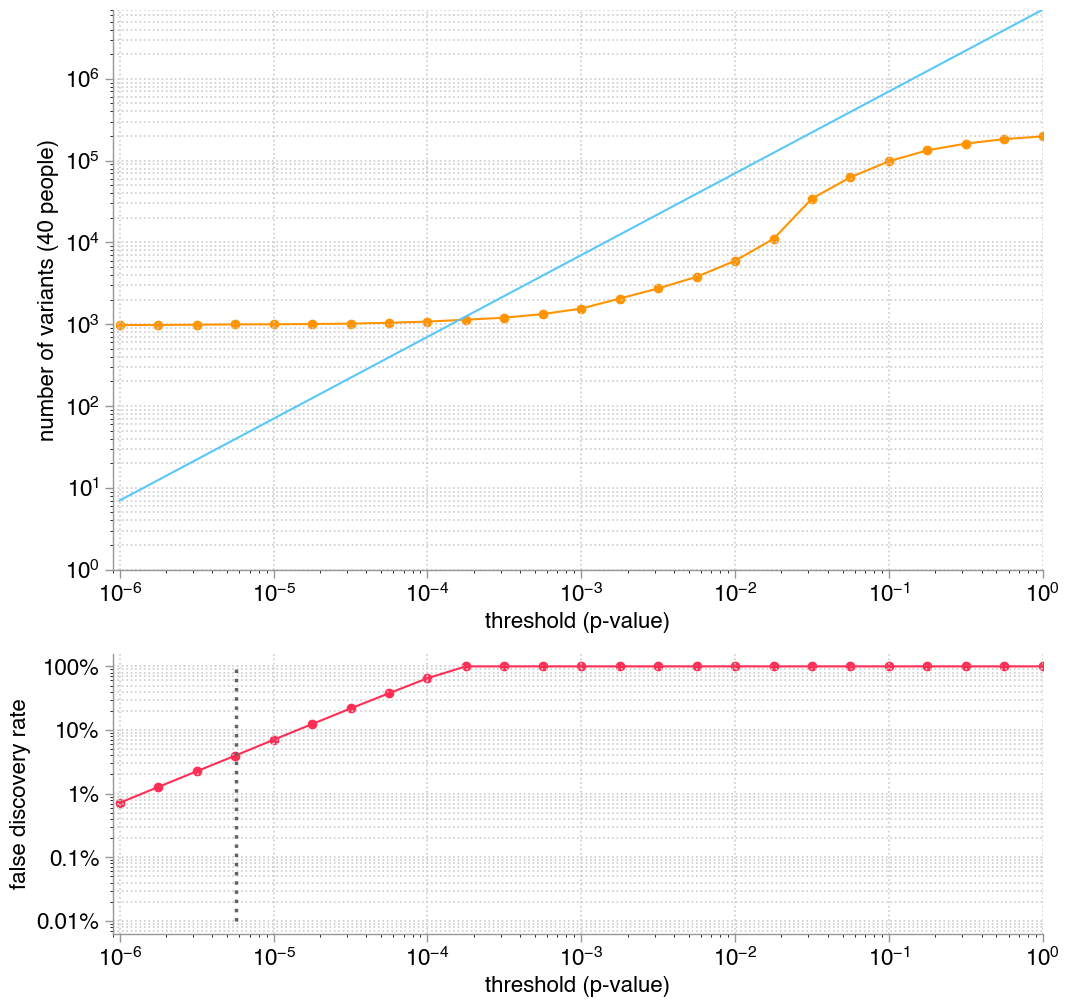

In [ ]:
#plot false discovery rate
fig, axes = plt.subplots(2, 1, figsize = (12, 12), gridspec_kw={'height_ratios':[2,1]})

number_positions = len(DCS_position_MLEs_cosmic_lowerp)

ax1 = axes[0]
ax2 = axes[1]

x1 = []
y1 = []

x2 = []
y2 = []

for k, v in FDR_by_p_value_cosmic_lowerp.items():
    x1.append(k)
    y1.append(v[0])
    
    x2.append(k)
    if v[2]<=1.0:
        y2.append(v[2])
    else:
        y2.append(1.0)

ax1.plot(x1, y1, color = c3)
ax1.scatter(x1, y1, color = c3)
    
ax2.plot(x2, y2, color = c1)
ax2.scatter(x2, y2, color = c1)

ax1.set_ylabel('number of variants (40 people)', fontsize = 16)
ax2.set_ylabel('false discovery rate', fontsize = 16)

# ax1.plot([1/(len(sim40filt_position_real_variants)*40), 1], [40, (len(sim40filt_position_MLEs)*40)], color = c6)
min_p_value = min(p_values_list)
max_p_value = max(p_values_list)

ax1.plot([min_p_value, 1], [min_p_value*40*number_positions, 40*number_positions], color = c6)

for ax in [ax1, ax2]:
    ax.set_xlabel('threshold (p-value)', fontsize = 16)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.xaxis.set_tick_params(width=1, color = grey3, length = 6)
    ax.yaxis.set_tick_params(width=1, color = grey3, length = 6)

    for item in (ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(16)

    #Only show the required axis lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1)
        ax.spines[axis].set_color(grey3)

    ax.grid(axis = 'y', which = 'both', lw = 1.2, zorder = 0, linestyle = ':', color = grey2)
    ax.grid(axis = 'x', which = 'major', lw = 1.2, zorder = 0, linestyle = ':', color = grey2)
    
ax2.set_yticks([0.0001, 0.001, 0.01, 0.1, 1.0])
ax2.set_yticklabels(['0.01%', '0.1%', '1%', '10%', '100%'])

ax2.plot([1/number_positions, 1/number_positions], [0.0001, 1.0], color = grey4, lw = 2.5, linestyle = ':')

ax1.set_xlim(9e-7, 1.0)
ax2.set_xlim(9e-7, 1.0)

ax1.set_ylim(1, number_positions*40)

plt.show()